In [ ]:
# CEFI Icechunk Creation Documentation
### Author: Eli Holmes

##  Workflow

1. Open a single nc file on S3 and create a virtual dataset
2. Write virtual references to an Icechunk store in cloud storage
3. Open the next nc file on S3 and create a virtual dataset
4. Append to the Icechunk store
5. Repeat

In [11]:
import warnings
import shutil
from pathlib import Path

import xarray as xr
import icechunk
from obstore.store import from_url
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obspec_utils.registry import ObjectStoreRegistry

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)

In [53]:
# Where the data are
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_prefix = "northeast_pacific/full_domain/hindcast/daily/regrid/r20250912"
source_data_region = "us-east-1"

# Where my icechunk is
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# Where my creds for my icechunk bucket are
icechunk_creds = "source-cefi-creds.json"

In [50]:
from pathlib import Path
import s3fs
fs = s3fs.S3FileSystem(anon=True)
source_data_prefix = "northeast_pacific/full_domain/hindcast/daily/regrid/r20250912"
filenames = sorted( f for f in fs.ls(f"{source_data_bucket}/{source_data_prefix}")  if f.endswith(".nc") )

def get_urls(varname):
    """Return sorted s3:// URLs for one variable."""
    return sorted(
        f if f.startswith("s3://") else f"s3://{f}"
        for f in filenames
        if Path(f).name.startswith(f"{varname}.nep.full.hcast.daily.regrid")
    )

# Get all variable names from the filenames
all_vars = sorted({
    Path(f).name.split(".nep.full.hcast.daily.regrid")[0]
    for f in filenames
})

# Keep only variables with 33 files
vars_33 = [
    varname for varname in all_vars
    if len(get_urls(varname)) == 33
]

# Keep only variables with 1 files
vars_1 = [
    varname for varname in all_vars
    if len(get_urls(varname)) == 1
]

In [54]:
# Create an object-store handle for the REMOTE files.
store = from_url(source_data_bucket, region=source_data_region, skip_signature=True)
registry = ObjectStoreRegistry({source_data_bucket: store})
parser = HDFParser()

# Tell the store how to access the remote chunks
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{source_data_bucket}/", # need that trailing /
        store=icechunk.s3_store(region=source_data_region, anonymous=True),
    ),
)

In [102]:
# Read in the json file
import json
from pathlib import Path

with open(icechunk_creds) as f:
    source_creds = json.load(f)

# This uses info on the bucket where the icechunk store is
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=source_creds["region_name"],
    access_key_id=source_creds["aws_access_key_id"],
    secret_access_key=source_creds["aws_secret_access_key"],
    session_token=source_creds["aws_session_token"],
)

# Create store if it is empty
try:
    repo = icechunk.Repository.create(storage, config)
    print("Created new Icechunk repo")
except Exception:
    repo = icechunk.Repository.open(storage, config=config)
    print("Opened existing Icechunk repo")

# Create a session
session = repo.writable_session(branch="main")

Created new Icechunk repo


## The 33 len vars

In [103]:
import numpy as np
import pandas as pd

template_var = "chlos"
group_name = "yearly"

def time_is_good(vds):
    t = pd.Index(vds.time.values)
    return t.is_unique and t.is_monotonic_increasing

for year_index in range(0,32):
    print(f"\nBuilding year block {year_index + 1}")

    # Open chlos first to get the trusted time coordinate
    template_vds = open_virtual_dataset(
        url=get_urls(template_var)[year_index],
        parser=parser,
        registry=registry,
        loadable_variables=["time", "lat", "lon", "z_l"],
        decode_times=True,
    ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

    template_time = template_vds.time

    vds_list = []
    
    for varname in vars_33:
        var_url = get_urls(varname)[year_index]

        print(f"  Opening {varname:20s} {Path(var_url).name}")

        vds = open_virtual_dataset(
            url=var_url,
            parser=parser,
            registry=registry,
            loadable_variables=["time", "lat", "lon", "z_l"],
            decode_times=True,
        ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

        vds = vds[[varname]]

        if not time_is_good(vds):
            print(f"    Repairing bad time coordinate for {varname}")
            vds = vds.assign_coords(time=template_time)

        vds_list.append(vds)

    vds_combined = xr.merge(
        vds_list,
        compat="override",
        join="exact",
        combine_attrs="drop_conflicts",
    )

    if year_index == 0:
        vds_combined.vz.to_icechunk(session.store, group=group_name)
    else:
        vds_combined.vz.to_icechunk(
            session.store,
            group=group_name,
            append_dim="time",
        )
snapshot_id = session.commit("yearly files")
print("Committed:", snapshot_id)


Building year block 1
  Opening chlos                chlos.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening dissic               dissic.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening no3                  no3.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening o2                   o2.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening phycos               phycos.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening po4                  po4.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening si                   si.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening so                   so.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening talk                 talk.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening thetao               thetao.nep.full.hcast.daily.regrid.r20250912.199301-199312.nc
  Opening volcello             volcello.nep.full.hcast.daily.regrid.

# Salinity has problems in 1999 and 2001

In [92]:
varname = "so"
year_index = 6
url = get_urls(varname)[year_index]
url
import xarray as xr
import fsspec
import pandas as pd

fs_s3 = fsspec.filesystem("s3", anon=True)

with fs_s3.open(url, "rb") as f:
    ds_real = xr.open_dataset(f, engine="h5netcdf", decode_times=True)

t = pd.Index(ds_real.time.values)

print("ntime:", ds_real.sizes["time"])
print("first:", ds_real.time.values[0])
print("last: ", ds_real.time.values[-1])
print("unique:", t.is_unique)
print("monotonic:", t.is_monotonic_increasing)

print(ds_real.time.values[300:365])

ntime: 365
first: 1999-01-01T12:00:00.000000000
last:  1999-12-31T12:00:00.000000000
unique: False
monotonic: False
['1999-10-28T12:00:00.000000000' '1999-10-29T12:00:00.000000000'
 '1999-10-30T12:00:00.000000000' '1999-10-31T12:00:00.000000000'
 '1999-11-01T12:00:00.000000000' '1999-11-02T12:00:00.000000000'
 '1999-11-03T12:00:00.000000000' '1999-11-04T12:00:00.000000000'
 '1999-11-05T12:00:00.000000000' '1999-11-06T12:00:00.000000000'
 '1999-11-07T12:00:00.000000000' '1999-11-08T12:00:00.000000000'
 '1999-11-09T12:00:00.000000000' '1999-11-10T12:00:00.000000000'
 '1999-11-11T12:00:00.000000000' '1999-11-12T12:00:00.000000000'
 '1999-11-13T12:00:00.000000000' '1999-11-14T12:00:00.000000000'
 '1999-11-15T12:00:00.000000000' '1999-11-16T12:00:00.000000000'
 '1999-11-17T12:00:00.000000000' '1999-11-18T12:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-01-01T00:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-01-01T00:00:00.000000000'
 '1993-01-01T00:00:00.000000000' '1993-

## Last year has problems

In [94]:
year_index = 32  # year 7, because Python is zero-based

for varname in vars_33:
    var_url = get_urls(varname)[year_index]

    vds = open_virtual_dataset(
        url=var_url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "lat", "lon", "z_l"],
        decode_times=True,
    ).drop_vars(["nv", "ncrs", "crs"], errors="ignore")

    print("\n", varname)
    print("  file:", Path(var_url).name)
    print("  ntime:", vds.sizes["time"])
    print("  first:", vds.time.values[0])
    print("  last: ", vds.time.values[-1])
    print("  unique:", len(set(vds.time.values)) == vds.sizes["time"])


 chlos
  file: chlos.nep.full.hcast.daily.regrid.r20250912.202501-202512.nc
  ntime: 234
  first: 2025-01-01T12:00:00.000000000
  last:  2025-08-22T12:00:00.000000000
  unique: True

 dissic
  file: dissic.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 no3
  file: no3.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 o2
  file: o2.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  first: 2025-01-01T12:00:00.000000000
  last:  2025-06-30T12:00:00.000000000
  unique: True

 phycos
  file: phycos.nep.full.hcast.daily.regrid.r20250912.202501-202512.nc
  ntime: 234
  first: 2025-01-01T12:00:00.000000000
  last:  2025-08-22T12:00:00.000000000
  unique: True

 po4
  file: po4.nep.full.hcast.daily.regrid.r20250912.202501-202506.nc
  ntime: 181
  fir

## Read in from the store

In [16]:
import icechunk
import xarray as xr

# -------------------------------------------------------------------
# 1. Source data: original NOAA CEFI NetCDF files
# -------------------------------------------------------------------
source_data_bucket = "s3://noaa-oar-cefi-regional-mom6-pds"
source_data_prefix = "northeast_pacific/full_domain/hindcast/daily/regrid/r20250912"
source_data_region = "us-east-1"

source_data_url_prefix = source_data_bucket.rstrip("/") + "/"

# -------------------------------------------------------------------
# 2. Icechunk repo: public Source Cooperative location
# -------------------------------------------------------------------
icechunk_bucket = "us-west-2.opendata.source.coop"
icechunk_prefix = "eeholmes/cefi/nepacific-icechunk"
icechunk_region = "us-west-2"

# -------------------------------------------------------------------
# 3. Authorize access to the original NOAA virtual chunks
# -------------------------------------------------------------------
# The Icechunk repo contains virtual references back to the public
# NOAA CEFI S3 bucket. Use anonymous access for these chunks.
credentials = icechunk.containers_credentials({
    source_data_url_prefix: icechunk.s3_credentials(anonymous=True)
})

# -------------------------------------------------------------------
# 4. Tell Icechunk which external virtual chunk locations are allowed
# -------------------------------------------------------------------
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=source_data_url_prefix,
        store=icechunk.s3_store(
            region=source_data_region,
            anonymous=True,
        ),
    ),
)

# -------------------------------------------------------------------
# 5. Point to the public Icechunk repo on Source Cooperative
# -------------------------------------------------------------------
storage = icechunk.s3_storage(
    bucket=icechunk_bucket,
    prefix=icechunk_prefix,
    region=icechunk_region,
    anonymous=True,
)

# -------------------------------------------------------------------
# 6. Open the Icechunk repo
# -------------------------------------------------------------------
repo = icechunk.Repository.open(
    storage,
    config=config,
    authorize_virtual_chunk_access=credentials,
)

session = repo.readonly_session(branch="main")

ds = xr.open_zarr(
    session.store,
    group="yearly",
    consolidated=False,
    chunks="auto",
)

ds

/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


<xarray.Dataset> Size: 7TB
Dimensions:    (time: 11688, lat: 815, lon: 341, z_l: 52)
Coordinates:
  * time       (time) datetime64[ns] 94kB 1993-01-01T12:00:00 ... 2024-12-31T...
  * lat        (lat) float64 7kB 10.81 10.89 10.98 11.07 ... 80.55 80.63 80.72
  * lon        (lon) float64 3kB 156.9 157.2 157.5 157.8 ... 254.4 254.7 255.0
  * z_l        (z_l) float64 416B 2.5 7.5 12.5 ... 5.25e+03 5.75e+03 6.25e+03
Data variables:
    chlos      (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    dissic     (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    si         (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    o2         (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    phycos     (time, lat, lon) float32 13GB dask.array<chunksize=(100, 200, 200), meta=np.ndarray>
    so         (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    po4        (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    thetao     (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    no3        (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    volcello   (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    vollcello  (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
    talk       (time, z_l, lat, lon) float32 676GB dask.array<chunksize=(100, 10, 200, 200), meta=np.ndarray>
Attributes: (12/22)
    NumFilesInSet:          1
    title:                  NEP10k_202507_physics_bgc
    associated_files:       areacello: 20240101.ocean_static.nc
    grid_type:              regular
    grid_tile:              N/A
    cefi_rel_path:          cefi_portal/northeast_pacific/full_domain/hindcas...
    ...                     ...
    cefi_init_date:         N/A
    cefi_ensemble_info:     N/A
    cefi_forcing:           N/A
    cefi_data_doi:          10.5281/zenodo.13936240
    cefi_paper_doi:         10.5194/gmd-2024-195
    cefi_aux:               Postprocessed Data : regrid to regular grid

In [ ]:
# Less safe for virtual/chunked arrays
ds["talk"].isel(time=0, z_l=0)

# Safer, less RAM explosion
ds["talk"].isel(time=slice(0, 1), z_l=slice(0, 1)).squeeze(drop=True)

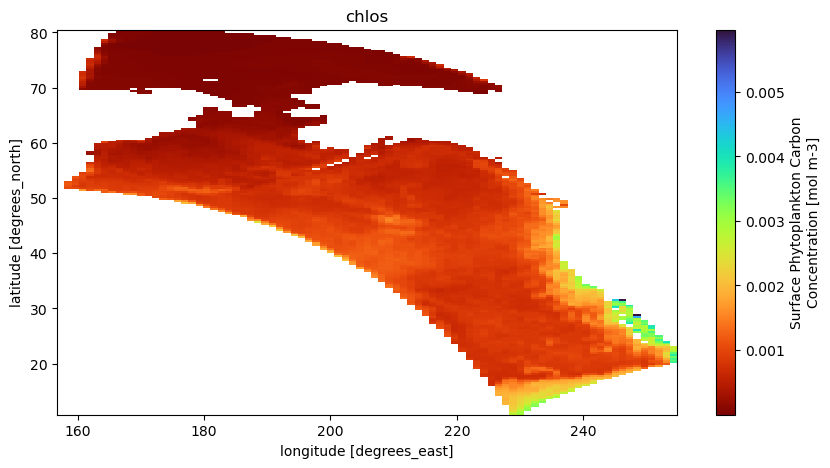

In [14]:
import matplotlib.pyplot as plt

da = ds["phycos"].isel(time=0).coarsen(
    lat=4,
    lon=4,
    boundary="trim",
).mean()

plt.figure(figsize=(10, 5))

da.plot(
    x="lon",
    y="lat",
    cmap="turbo_r",
)

plt.title("chlos")
plt.show()

In [15]:
import hvplot.xarray

da = (
    ds["talk"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da.hvplot.quadmesh(
    rasterize=True,
    x="lon",
    y="lat",
    width=800,
    height=400,
    cmap = "turbo_r"
)

:DynamicMap   []
   :Image   [lon,lat]   (Total Alkalinity)

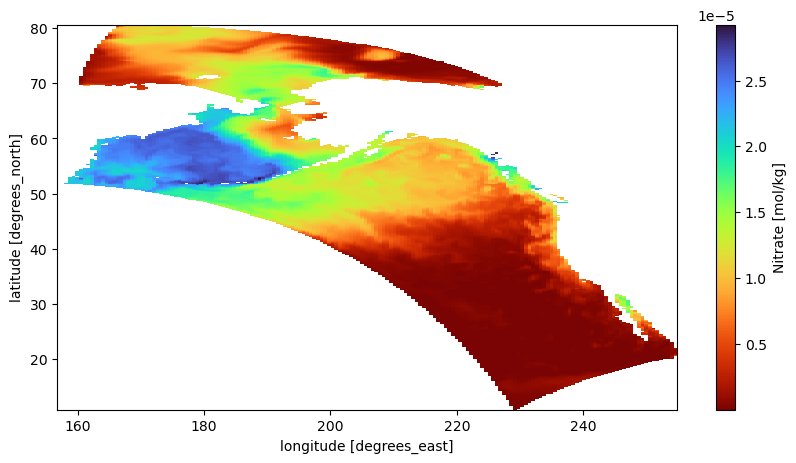

In [8]:
da = (
    ds["no3"]
    .isel(time=slice(0, 1), z_l=slice(0, 1))
    .squeeze(drop=True)
)

da_small = da.coarsen(
    lat=2,
    lon=2,
    boundary="trim",
).mean()

da_small.plot(
    x="lon",
    y="lat",
    figsize=(10, 5),
    cmap = "turbo_r"
)